In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [8]:
df = pd.read_csv('CAISOHourlyLoadCSV.csv')


In [13]:
dt_naive = (
    pd.to_datetime(df["Date"], format="%m/%d/%Y") +
    pd.to_timedelta(df["Hour"] - 1, unit="h")
)

df["datetime"] = dt_naive.dt.tz_localize(
    "America/Los_Angeles",
    ambiguous="NaT",    
    nonexistent="NaT"   
)

dst_bad = df["datetime"].isna()
df.loc[dst_bad, ["Date", "Hour"]].head()


,Date,Hour
datetime,,
NaT,11/3/2024,2
NaT,3/9/2025,3


In [15]:
df = df[df.index.notna()].copy()
df = df.set_index("datetime").sort_index()

 EDA

Text(0.5, 1.0, 'CAISO Hourly Load Time Series')

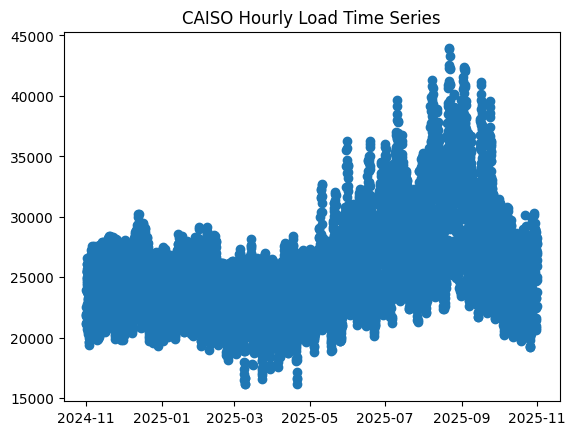

In [16]:
plt.scatter(df.index, df["CAISO Load (MW)"])
plt.title("CAISO Hourly Load Time Series")


Text(0.5, 1.0, 'CAISO Load in March 2025')

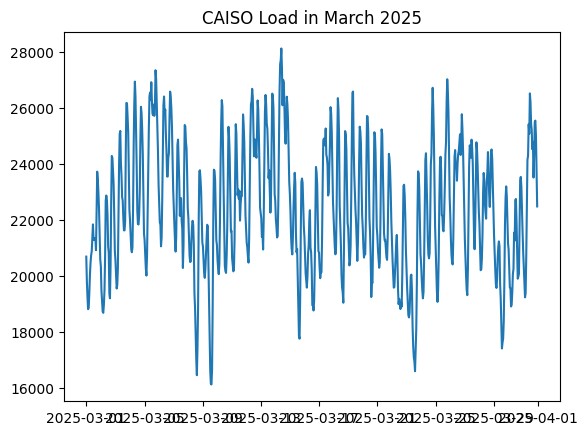

In [17]:
sorted = df["CAISO Load (MW)"].sort_index()
start, end = "2025-03-01", "2025-03-31"
window = sorted.loc[start:end]
plt.plot(window.index, window.values)
plt.title("CAISO Load in March 2025")

Text(0.5, 1.0, 'Monthly Maximum CAISO Load')

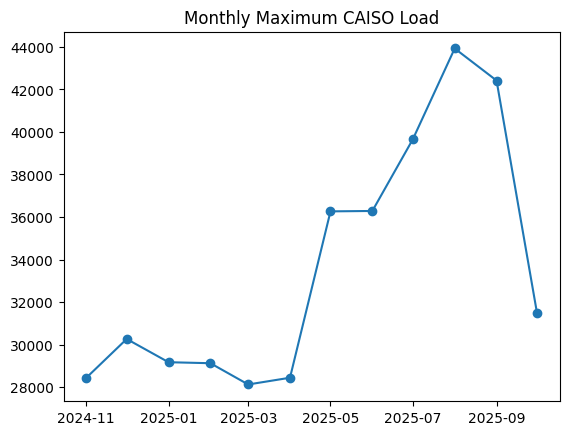

In [18]:
monthly_max = df["CAISO Load (MW)"].sort_index().resample("MS").max()
plt.plot(monthly_max.index, monthly_max.values, marker="o", linestyle="-")
plt.title("Monthly Maximum CAISO Load")


Convert hourly to monthly max

In [19]:
idx = df.groupby([df.index.year, df.index.month])["CAISO Load (MW)"].idxmax()

monthly_peak = (
    df.loc[idx, ["CAISO Load (MW)"]]
      .rename(columns={"CAISO Load (MW)": "Monthly Peak MW"})
      .assign(
          Year=lambda x: x.index.year,
          Month=lambda x: x.index.month,
          Date_of_Peak=lambda x: x.index
      )
      .reset_index(drop=True)
      .sort_values(["Year", "Month"])
)

monthly_peak

,Monthly Peak MW,Year,Month,Date_of_Peak
0,28434.06,2024,11,2024-11-20 11:00:00-08:00
1,30265.19,2024,12,2024-12-13 09:00:00-08:00
2,29173.90,2025,1,2025-01-31 09:00:00-08:00
3,29126.53,2025,2,2025-02-06 11:00:00-08:00
4,28127.03,2025,3,2025-03-14 10:00:00-07:00
5,28444.29,2025,4,2025-04-17 09:00:00-07:00
6,36265.24,2025,5,2025-05-30 18:00:00-07:00
7,36284.07,2025,6,2025-06-18 18:00:00-07:00
8,39655.38,2025,7,2025-07-10 18:00:00-07:00
9,43922.82,2025,8,2025-08-21 18:00:00-07:00


Baseline Model

In [20]:
train = df.loc[: "2025-02-28"]
march = df.loc["2025-03-01" : "2025-03-31"]
train = train.copy()
train["hour_of_week"] = (
    train.index.dayofweek * 24 + train.index.hour
)
hourly_baseline = (
    train.groupby("hour_of_week")["CAISO Load (MW)"]
         .mean()
)
march = march.copy()
march["hour_of_week"] = (
    march.index.dayofweek * 24 + march.index.hour
)

march["naive_pred"] = march["hour_of_week"].map(hourly_baseline)
from sklearn.metrics import mean_absolute_error

actual_peak = march["CAISO Load (MW)"].max()
predicted_peak = march["naive_pred"].max()

peak_error = abs(actual_peak - predicted_peak)
percent_error = peak_error / actual_peak * 100

print(f"Actual Peak: {actual_peak:.2f} MW")
print(f"Predicted Peak: {predicted_peak:.2f} MW")
print(f"Peak Error: {peak_error:.2f} MW")


Actual Peak: 28127.03 MW
Predicted Peak: 27260.81 MW
Peak Error: 866.22 MW


Primary Model

In [21]:
monthly_peak["MonthStart"] = pd.to_datetime(
    monthly_peak["Year"].astype(str) + "-" + monthly_peak["Month"].astype(str).str.zfill(2) + "-01"
)
monthly_peak = monthly_peak.sort_values("MonthStart").reset_index(drop=True)

monthly_peak.head()

,Monthly Peak MW,Year,Month,Date_of_Peak,MonthStart
0,28434.06,2024,11,2024-11-20 11:00:00-08:00,2024-11-01
1,30265.19,2024,12,2024-12-13 09:00:00-08:00,2024-12-01
2,29173.90,2025,1,2025-01-31 09:00:00-08:00,2025-01-01
3,29126.53,2025,2,2025-02-06 11:00:00-08:00,2025-02-01
4,28127.03,2025,3,2025-03-14 10:00:00-07:00,2025-03-01


In [22]:
from sklearn.linear_model import LinearRegression

# Feature engineering: time index + month dummies
monthly_peak["t"] = np.arange(len(monthly_peak), dtype=float)

X = pd.get_dummies(monthly_peak[["t", "Month"]], columns=["Month"], drop_first=True)
y = monthly_peak["Monthly Peak MW"].astype(float)

model = LinearRegression()
model.fit(X, y)

# Optional: interpret key coefficients
coef = pd.Series(model.coef_, index=X.columns).sort_values()
intercept = model.intercept_

print("Intercept:", intercept)
print("\nTop 10 coefficients (most negative to most positive):")
print(coef.tail(10))


Intercept: 26749.540412371145

Top 10 coefficients (most negative to most positive):
Month_3    -3471.229588
Month_2    -1259.549794
Month_6     1049.271031
t           1212.179794
Month_11    1684.519588
Month_5     2242.620825
Month_12    2303.469794
Month_7     3208.401237
Month_9     3545.101649
Month_8     6263.661443
dtype: float64


In [23]:
from sklearn.metrics import mean_absolute_error

def rolling_one_step_backtest(monthly_peak, start_train=6):
    mp = monthly_peak.sort_values("MonthStart").reset_index(drop=True).copy()
    mp["t"] = np.arange(len(mp), dtype=float)

    preds = []
    actuals = []
    dates = []

    for i in range(start_train, len(mp)):
        train = mp.iloc[:i].copy()
        test = mp.iloc[i:i+1].copy()

        X_train = pd.get_dummies(train[["t", "Month"]], columns=["Month"], drop_first=True)
        y_train = train["Monthly Peak MW"].astype(float)

        X_test = pd.get_dummies(test[["t", "Month"]], columns=["Month"], drop_first=True)

        # Align columns so train/test match
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

        m = LinearRegression()
        m.fit(X_train, y_train)

        y_pred = float(m.predict(X_test)[0])
        y_true = float(test["Monthly Peak MW"].iloc[0])

        preds.append(y_pred)
        actuals.append(y_true)
        dates.append(test["MonthStart"].iloc[0])

    out = pd.DataFrame({"MonthStart": dates, "y_true": actuals, "y_pred": preds})
    out["abs_error_mw"] = (out["y_true"] - out["y_pred"]).abs()
    out["pct_error"] = out["abs_error_mw"] / out["y_true"] * 100
    return out

bt = rolling_one_step_backtest(monthly_peak, start_train=6)

print("Backtest MAE (monthly peak MW):", mean_absolute_error(bt["y_true"], bt["y_pred"]))
print("Backtest mean % error:", bt["pct_error"].mean())
bt.tail(12)


Backtest MAE (monthly peak MW): 5807.730532942561
Backtest mean % error: 16.140233301396304


,MonthStart,y_true,y_pred,abs_error_mw,pct_error
0,2025-05-01,36265.24,28385.590000,7879.650000,21.727831
1,2025-06-01,36284.07,32566.095833,3717.974167,10.246850
2,2025-07-01,39655.38,35073.046885,4582.333115,11.555388
3,2025-08-01,43922.82,38040.341031,5882.478969,13.392763
4,2025-09-01,42416.44,41563.268767,853.171233,2.011416
5,2025-10-01,31473.68,43404.455714,11930.775714,37.907152


In [25]:
mp = monthly_peak.copy()

if "MonthStart" not in mp.columns:
    mp["MonthStart"] = pd.to_datetime(
        mp["Year"].astype(str) + "-" + mp["Month"].astype(str).str.zfill(2) + "-01"
    )

mp = mp.sort_values("MonthStart").reset_index(drop=True)

mp = mp.sort_values("MonthStart").reset_index(drop=True)

mp["MoM_Delta_MW"] = mp["Monthly Peak MW"].diff()

avg_mom_delta = mp["MoM_Delta_MW"].dropna().mean()

print("Average month-to-month change in peak (MW):", avg_mom_delta)
march_hist = mp[mp["Month"] == 3].sort_values("Year")

if len(march_hist) == 0:
    raise ValueError("No historical March peak found in monthly_peak. Need at least one March.")

anchor = march_hist.iloc[-1]
anchor_year = int(anchor["Year"])
anchor_peak = float(anchor["Monthly Peak MW"])
anchor_peak_ts = pd.to_datetime(anchor["Date_of_Peak"])

print(f"Anchor March: {anchor_year}, peak={anchor_peak:.2f} MW, occurred on {anchor_peak_ts.date()}")

months_ahead = 12  # March 2025 → March 2026

march_2026_peak_forecast = anchor_peak + months_ahead * avg_mom_delta

print("Forecast March 2026 peak MW:", march_2026_peak_forecast)

march_hist = march_hist.copy()
march_hist["PeakDay"] = pd.to_datetime(march_hist["Date_of_Peak"]).dt.day

day_guess = int(round(march_hist["PeakDay"].median()))
day_guess = max(1, min(31, day_guess))  # keep valid for March

march_2026_peak_date_guess = pd.Timestamp(f"2026-03-{day_guess:02d}").date()

print("Forecast March 2026 peak date (heuristic):", march_2026_peak_date_guess)

Average month-to-month change in peak (MW): 276.32909090909084
Anchor March: 2025, peak=28127.03 MW, occurred on 2025-03-14
Forecast March 2026 peak MW: 31442.979090909088
Forecast March 2026 peak date (heuristic): 2026-03-14


## March 2026 Forecast Diagrams

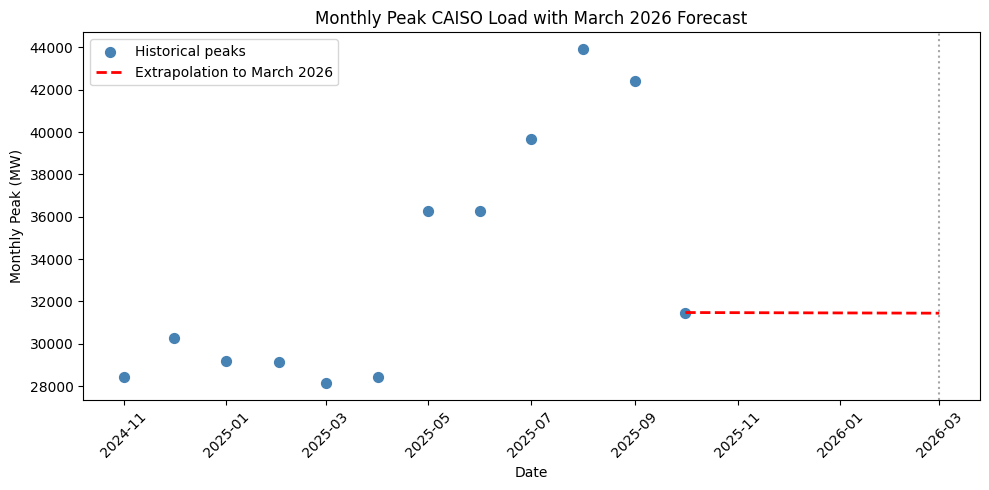

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
mp_plot = monthly_peak.sort_values("MonthStart").reset_index(drop=True)

ax.scatter(mp_plot["MonthStart"], mp_plot["Monthly Peak MW"], color="steelblue", s=50, label="Historical peaks")

last_date = mp_plot["MonthStart"].iloc[-1]
last_peak = mp_plot["Monthly Peak MW"].iloc[-1]
march_2026 = pd.Timestamp("2026-03-01")
ax.plot([last_date, march_2026], [last_peak, march_2026_peak_forecast], "r--", linewidth=2, label="Extrapolation to March 2026")

ax.axvline(march_2026, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Peak (MW)")
ax.set_title("Monthly Peak CAISO Load with March 2026 Forecast")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

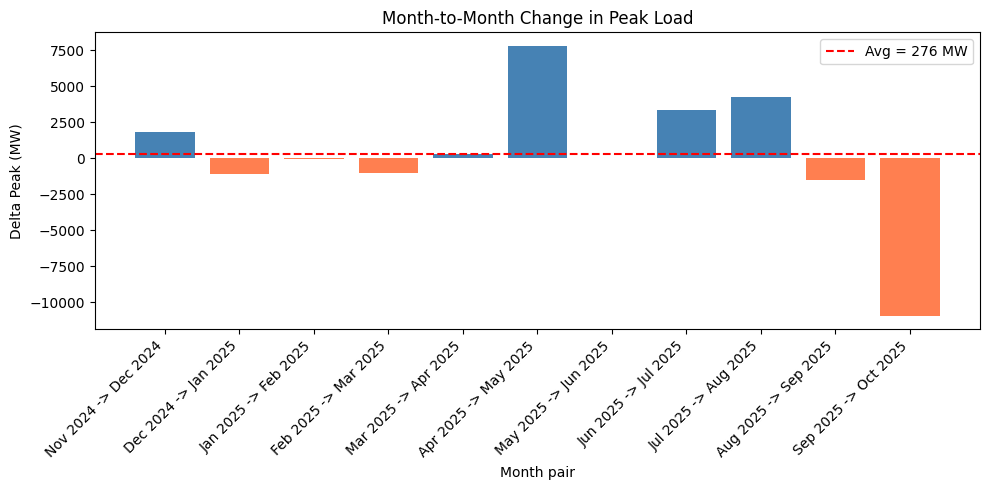

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
mp_sorted = mp.sort_values("MonthStart").reset_index(drop=True)
deltas = mp_sorted["MoM_Delta_MW"].dropna()

labels = [
    f"{mp_sorted.loc[i-1, 'MonthStart'].strftime('%b %Y')} -> {mp_sorted.loc[i, 'MonthStart'].strftime('%b %Y')}"
    for i in deltas.index
]
colors = ["steelblue" if d >= 0 else "coral" for d in deltas.values]
ax.bar(range(len(deltas)), deltas.values, color=colors)
ax.axhline(avg_mom_delta, color="red", linestyle="--", linewidth=1.5, label=f"Avg = {avg_mom_delta:.0f} MW")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Month pair")
ax.set_ylabel("Delta Peak (MW)")
ax.set_title("Month-to-Month Change in Peak Load")
ax.legend()
plt.tight_layout()
plt.show()